In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf

In [2]:
seed = 10
HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

#Discontinuous Benchmark           
#lowfid = lambda x: (0.5*(6.*x-2.)**2*np.sin(12.*x-4)+10.*(x-0.5)-5.)*(x<0.5) + (3+0.5*(6.*x-2)**2*np.sin(12.*x-4)+10*(x-0.5)-5.)*(x>0.5)
#highfid = lambda x: (2*lowfid(x)- 20*x+20)*(x<0.5) + (4+2*lowfid(x)- 20*x+20)*(x>0.5)
#Nhf = 6
#Nlf = 32
#N = Nhf + Nlf
#xhf = np.linspace(0,1,Nhf)
#xlf = np.linspace(0,1,Nlf)
#NepoLF = 5000
#NepoHF = 1200
            
#Nonlinear correlation
#lowfid = lambda x: np.sin(8*pi*x)
#highfid = lambda x: (x-np.sqrt(2))*lowfid(x)**2
#Nhf = 15
#Nlf = 64
#N = Nhf + Nlf
#xhf = np.linspace(0,1,Nhf)
#xlf = np.linspace(0,1,Nlf)
#NepoLF = 3000
#NepoHF = 3000

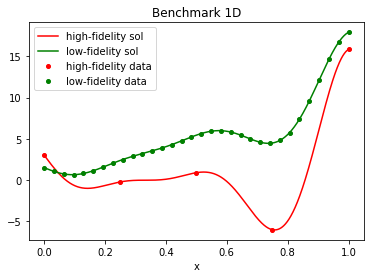

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()


In [4]:
### LF
K.clear_session()
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF = getModel(bestLF_params,'LF')
tf.random.set_seed(seed)
histLF = modelLF.fit(xlf,Ylf,epochs=NepoLF,batch_size=Nlf,verbose=0)
yLF = modelLF.predict(x_test)[:,0]

32/32 [==============================] - 0s 2ms/step


In [5]:
### HF single-fidelity
K.clear_session()
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF = getModel(bestHF_params,'LF')
tf.random.set_seed(seed)
histHF = modelHF.fit(xhf,Yhf,epochs=NepoHF,batch_size=Nhf,verbose=0)
yHF = modelHF.predict(x_test)[:,0]

32/32 [==============================] - 0s 1ms/step


In [6]:
### 2-step
xhf_help = modelLF.predict(xhf)[:,0]
xhf = np.vstack((xhf,xhf_help)).transpose()

x_test_help = modelLF.predict(x_test)[:,0]
x_test_in = np.vstack((x_test,x_test_help)).transpose()
y_test_in = highfid(x_test)

name = '2step'
if HPO:
    MAX_EVAL = 30
    bayes_trials = Trials()
    opt_list = ['Adam','Adamax']
    kernel_list = ['uniform','glorot_uniform']
    aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
    space = {
        'nodes' : scope.int(hp.qloguniform('nodes',np.log(16),np.log(128),2)),
        'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(1)),
        'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
        'kernel_init': hp.choice('kernel_init',kernel_list),
        'opt' : hp.choice('opt',opt_list)}

    def objective(params):
        K.clear_session()
        print(params)
        CVres = kCrossVal(Nhf,NepoHF,xhf,Yhf,params,name)
        return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

    best_params = fmin(fn = objective,
                    space = space,
                    algo = tpe.suggest,
                    max_evals = MAX_EVAL,
                    trials = bayes_trials)

    K.clear_session()
    transfBestparam(best_params,aux_dic)
    print('best parameters: ', best_params)
else:
    best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}

finalModel = getModel(best_params,name)
hist = finalModel.fit(xhf,Yhf,epochs=NepoHF,batch_size=Nhf,verbose=0)#, validation_data=[x_test_in,y_test_in]) 
#remove validation if it is too slow!
yMF = finalModel.predict(x_test_in)

32/32 [==============================] - 0s 1ms/step


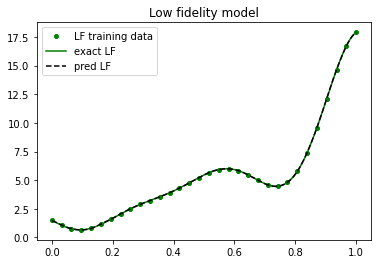

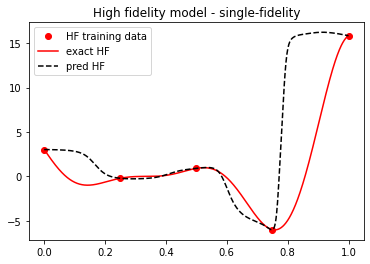

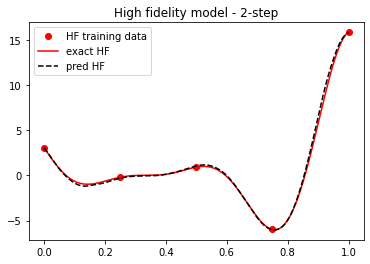

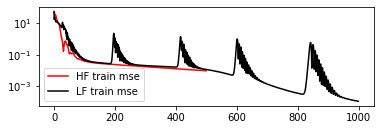

In [7]:
### Plots

#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yMF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

plt.figure()
plt.subplot(2,1,1)
plt.plot(hist.history['loss'],color='red',label='HF train mse')
plt.plot(histLF.history['loss'],color='black',label='LF train mse')
plt.legend()
plt.yscale('log')
#plt.subplot(2,1,2)
#plt.plot(hist.history['val_loss'],color='red', label = 'HF validation mse')
#plt.legend()
#plt.yscale('log')

In [8]:
#%% MCMC
import sys
import os

model = finalModel


# Define the forward model
def forward_model_MF(x):
    with Suppressor():      
        ylf_pred = modelLF.predict(np.array([x]))[:,0]
    x_ = np.vstack((x,ylf_pred)).transpose()
    with Suppressor():
        y = model.predict(x_)[:,0]
    return y

def forward_model_HF(x):
    with Suppressor():
        y = modelHF.predict(np.array([x]))[:,0]
    return y

# def forward_model_LF(x):
#     with Suppressor():
#         y = modelLF.predict(np.array([x]))[:,0]
#     return y

# Define the likelihood function
def likelihood(x, y, forward_model):
    # Assuming a Gaussian likelihood for demonstration
    # Replace this with the appropriate likelihood function based on your problem
    y_hat = forward_model(x)
    variance = 1.0  # Example variance, adjust based on your problem
    return np.exp(-(y - y_hat)**2 / (2 * variance))

# Define the prior distribution for x
def prior(x):
    # Assuming a uniform prior in the range [0, 1]
    if 0 <= x <= 1:
        return 1.0
    else:
        return 0.0
    
# Define the Metropolis-Hastings algorithm
def metropolis_hastings(likelihood, prior, y, n_samples, init_x, proposal_sd, forward_model, verbose = False):
    samples = [init_x]
    current_x = init_x

    for i in range(n_samples):
        if i % 10 == 0 and verbose:
            print(i,'/',n_samples)
        proposed_x = np.random.normal(current_x, proposal_sd)
        
        # Calculate acceptance ratio
        acceptance_ratio = min(1, (likelihood(proposed_x, y, forward_model) * prior(proposed_x)) /
                                   (likelihood(current_x, y, forward_model) * prior(current_x)))
        
        # Accept or reject the proposal
        if np.random.uniform(0, 1) < acceptance_ratio:
            current_x = proposed_x
            if verbose:
                print('new value: ',current_x)
        samples.append(current_x)
    return np.array(samples)

In [10]:
# TEST 1: MCMC with MF
real_x = 0.9
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

# Run Metropolis-Hastings algorithm
forw_model = forward_model_MF
samples = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose = True)

0 / 300
new value:  0.5520617832910982
new value:  0.5621372064200362
new value:  0.5457292904979034
new value:  0.5345206034431352
10 / 300
new value:  0.9022630529948483
20 / 300
new value:  0.8950982036605244
30 / 300
40 / 300
50 / 300
new value:  0.9023358006105079
60 / 300
70 / 300
80 / 300
90 / 300
new value:  0.893220973074968
100 / 300
110 / 300
120 / 300
130 / 300
new value:  0.8967275855077469
140 / 300
150 / 300
160 / 300
170 / 300
new value:  0.8881130130277339
180 / 300
190 / 300
200 / 300
210 / 300
new value:  0.8933559118423168
220 / 300
new value:  0.8992606613109377
230 / 300
240 / 300
250 / 300
new value:  0.8978045762057655
260 / 300
270 / 300
280 / 300
290 / 300


In [11]:
#%% TEST 1: MCMC with HF single-fidelity
forw_model = forward_model_HF
samples_HF = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose = True)

0 / 300
new value:  0.5452142425666603
new value:  0.5914633464877932
10 / 300
new value:  0.1260671231542465
new value:  0.13019878569463936
new value:  0.08956123311753383
20 / 300
new value:  0.06744028142560057
30 / 300
new value:  0.08378937890745677
new value:  0.03709207044030812
new value:  0.041572113535968805
40 / 300
new value:  0.0014680723950305091
50 / 300
new value:  0.013104458643184373
60 / 300
70 / 300
80 / 300
90 / 300
new value:  0.027802281317992575
100 / 300
110 / 300
new value:  0.05392290193707641
new value:  0.021235700000871126
120 / 300
new value:  0.0019491473264754353
new value:  0.0074649656991110465
130 / 300
new value:  0.04235544840653747
new value:  0.012230978012745822
140 / 300
new value:  0.03252650756538197
150 / 300
new value:  0.0411382121240255
new value:  0.01716398350307234
160 / 300
170 / 300
new value:  0.02603347999211523
new value:  0.05724738827571642
180 / 300
new value:  0.05883203492232647
190 / 300
200 / 300
new value:  0.051904278004

In [12]:
#%% TEST 1: MCMC with LF
forw_model = forward_model_LF
samples_LF = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose = True)

0 / 300
new value:  0.6380763112356814
new value:  0.7383614953657506
new value:  0.6488256076341072
new value:  0.5383306523178943
10 / 300
new value:  0.577926416002907
new value:  0.4283401316247448
new value:  0.444243451237892
new value:  0.47933894634675783
new value:  0.6391482852863284
new value:  0.5721991207071215
20 / 300
new value:  0.5879511127745731
new value:  0.758172310089895
new value:  0.5809288703595138
new value:  0.4767046857877076
new value:  0.7813215535447604
30 / 300
new value:  0.4599668837640557
new value:  0.703195384335416
new value:  0.8187592696971483
new value:  0.6721195299338456
new value:  0.6422899243337984
40 / 300
new value:  0.49495738948735
new value:  0.6653961480607058
new value:  0.5415844775487112
new value:  0.6271175816340899
new value:  0.7875764971023861
new value:  0.611642643066776
new value:  0.5797184545252219
50 / 300
new value:  0.5642174088725367
new value:  0.48514284047782946
new value:  0.5500336560886429
new value:  0.63510235

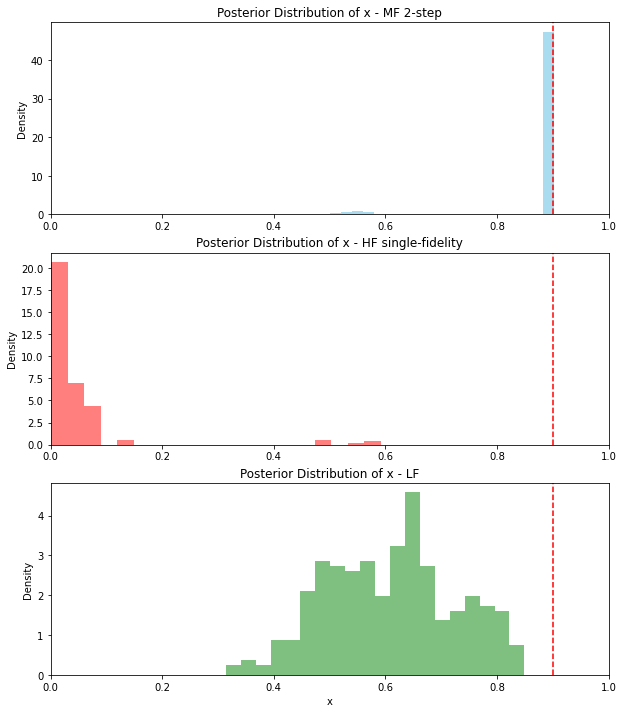

In [13]:
#Plot all denisities plot:
plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.hist(samples, bins=20, density=True, alpha=0.7, color='skyblue')
plt.title('Posterior Distribution of x - MF 2-step')
plt.axvline(x=real_x, color='red', linestyle='--')  
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.subplot(3,1,2)
plt.hist(samples_HF, bins=20, density=True, alpha=0.5, color='red')
plt.title('Posterior Distribution of x - HF single-fidelity')
plt.axvline(x=real_x, color='red', linestyle='--')
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.subplot(3,1,3)
plt.hist(samples_LF, bins=20, density=True, alpha=0.5, color='green')
plt.title('Posterior Distribution of x - LF')
plt.axvline(x=real_x, color='red', linestyle='--')
plt.xlabel('x')
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.show()

In [19]:
# TEST 2
real_x = 0.7
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

# Run Metropolis-Hastings algorithm
forw_model = forward_model_MF
samples = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose= True)

0 / 300
new value:  0.24551513559335497
new value:  0.361629970550454
new value:  0.31406511368579954
10 / 300
new value:  0.23209898800574963
new value:  0.41764552568895286
new value:  0.6068705146571653
new value:  0.30961216112756207
new value:  0.23468891689669324
20 / 300
new value:  0.17949979461106486
new value:  0.7532957152682989
new value:  0.7530512095171789
new value:  0.8132898118678085
30 / 300
new value:  0.7388730881187024
40 / 300
50 / 300
new value:  0.7167914385992836
60 / 300
new value:  0.7682205535804935
new value:  0.7019704867667834
70 / 300
new value:  0.6954466714023172
new value:  0.7228204447878303
new value:  0.7795838344604643
80 / 300
new value:  0.6548649705097765
new value:  0.6714648815559803
new value:  0.8036554756523786
90 / 300
new value:  0.7132502719802749
new value:  0.8055135307252619
100 / 300
new value:  0.8126384007419509
new value:  0.7144687661898269
110 / 300
new value:  0.8048595242779952
new value:  0.6781511406533102
120 / 300
new val

In [20]:
#%% TEST 2: MCMC with HF single-fidelity
forw_model = forward_model_HF
samples_HF = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose = True)

0 / 300
new value:  0.691065544591229
10 / 300
new value:  0.7471430128154385
new value:  0.7029078957361322
new value:  0.7466510165627489
20 / 300
new value:  0.7082557440348627
30 / 300
new value:  0.7213454318282237
new value:  0.7147881910684818
40 / 300
50 / 300
new value:  0.7665329068132153
60 / 300
70 / 300
80 / 300
new value:  0.7084591006247861
90 / 300
new value:  0.7264618234302053
100 / 300
110 / 300
120 / 300
130 / 300
new value:  0.693943177504036
140 / 300
new value:  0.7293161289710638
150 / 300
160 / 300
170 / 300
new value:  0.7438645569040289
180 / 300
new value:  0.7210909591830481
new value:  0.7607404422261275
190 / 300
200 / 300
new value:  0.7112047350835131
210 / 300
new value:  0.7337986526638149
new value:  0.766343319024584
220 / 300
new value:  0.7208521244532494
new value:  0.7244214817463343
new value:  0.728205208527305
230 / 300
new value:  0.7330219324670749
new value:  0.6994147411167562
240 / 300
new value:  0.6989313736634065
new value:  0.7434693

In [21]:
#%% TEST 2: MCMC with LF
forw_model = forward_model_LF
samples_LF = metropolis_hastings(likelihood, prior, observed_output, n_samples, initial_x, proposal_sd, forw_model, verbose = True)


0 / 300
new value:  0.09468058031587684
new value:  0.054683691044994064
10 / 300
new value:  0.09371289743747954
new value:  0.11379809732968654
20 / 300
new value:  0.002558043485773931
30 / 300
new value:  0.13734341406417533
new value:  0.1096990359683647
new value:  0.11882644604305816
40 / 300
new value:  0.040234722780713106
50 / 300
new value:  0.14156082539409603
new value:  0.05494464671794698
60 / 300
new value:  0.06197137007292947
new value:  0.18194332579212427
new value:  0.1738331952233631
new value:  0.08653487175904752
70 / 300
new value:  0.006215940899690006
new value:  0.09630860907830815
new value:  0.09291466361088718
80 / 300
new value:  0.1382831871873283
new value:  0.1543074436663194
new value:  0.17027742543663635
90 / 300
new value:  0.00678451487517609
new value:  0.06923050741676859
100 / 300
new value:  0.12436033103246066
new value:  0.0013483245519175097
110 / 300
new value:  0.013986395191360055
120 / 300
new value:  0.07177693598738992
new value:  0.

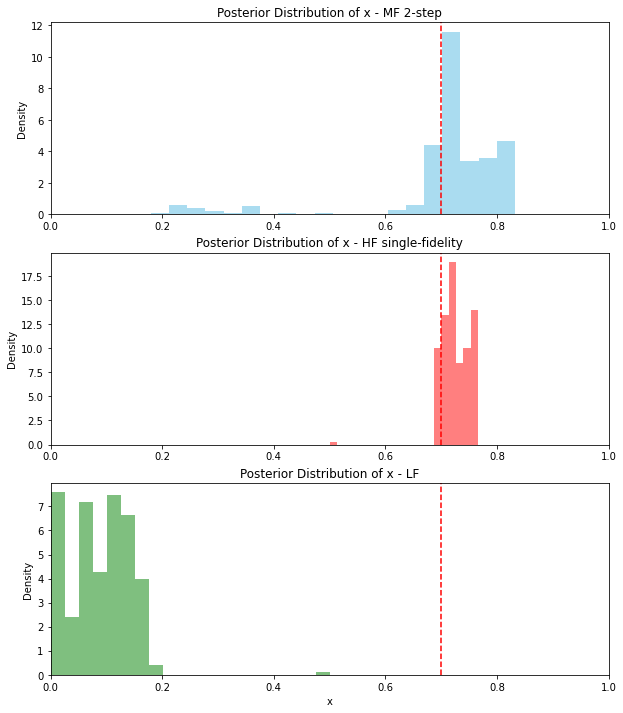

In [22]:
#Plot all denisities plot:
plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.hist(samples, bins=20, density=True, alpha=0.7, color='skyblue')
plt.title('Posterior Distribution of x - MF 2-step')
plt.axvline(x=real_x, color='red', linestyle='--')  
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.subplot(3,1,2)
plt.hist(samples_HF, bins=20, density=True, alpha=0.5, color='red')
plt.title('Posterior Distribution of x - HF single-fidelity')
plt.axvline(x=real_x, color='red', linestyle='--')
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.subplot(3,1,3)
plt.hist(samples_LF, bins=20, density=True, alpha=0.5, color='green')
plt.title('Posterior Distribution of x - LF')
plt.axvline(x=real_x, color='red', linestyle='--')
plt.xlabel('x')
plt.xlim(0.,1.)
plt.ylabel('Density')
plt.show()